
=== Subject S40 ===
Processing S40_A01_T01.raw
  qsLLL: 33 peaks, 29 troughs


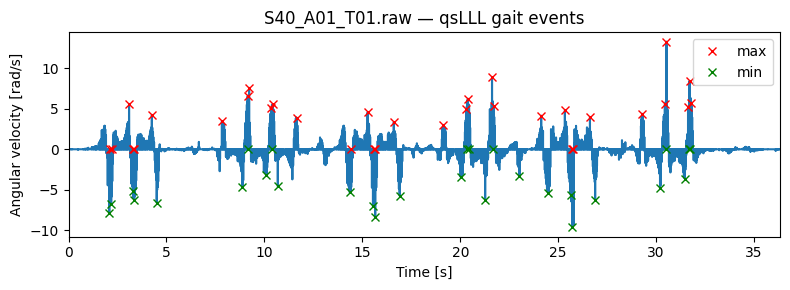

  qsRLL: 80 peaks, 80 troughs


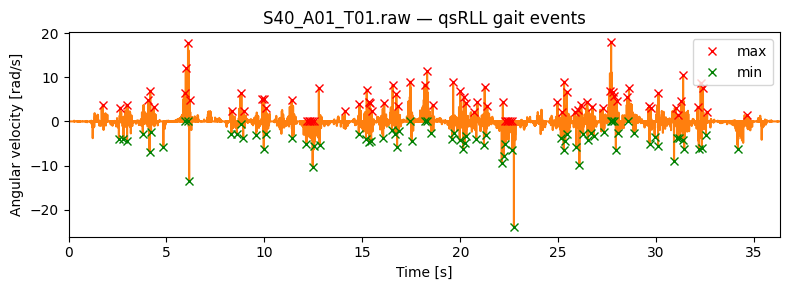


=== Subject S41 ===
Processing S41_A01_T02.raw
  qsLLL: 42 peaks, 38 troughs


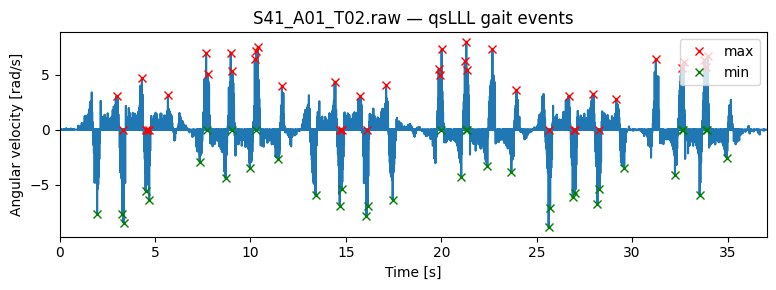

  qsRLL: 32 peaks, 37 troughs


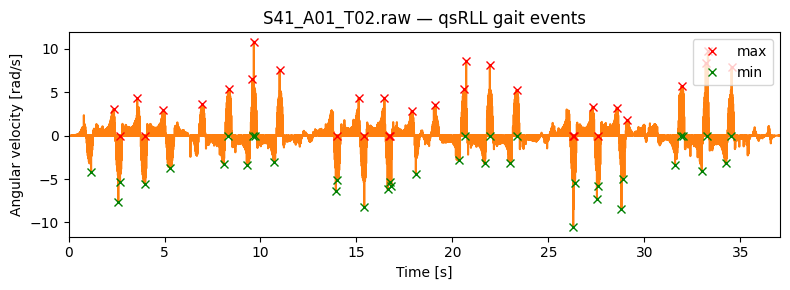


=== Subject S42 ===
Processing S42_A01_T01.raw
  qsLLL: 21 peaks, 23 troughs


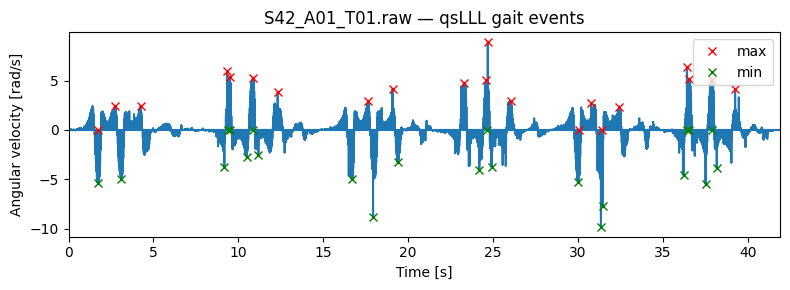

  qsRLL: 22 peaks, 19 troughs


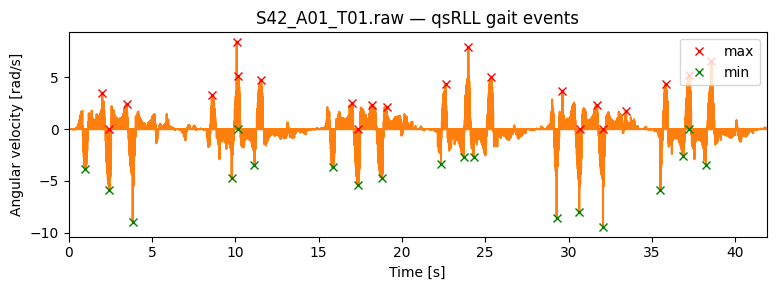


=== Subject S44 ===
Processing S44_A01_T01.raw
  qsLLL: 24 peaks, 25 troughs


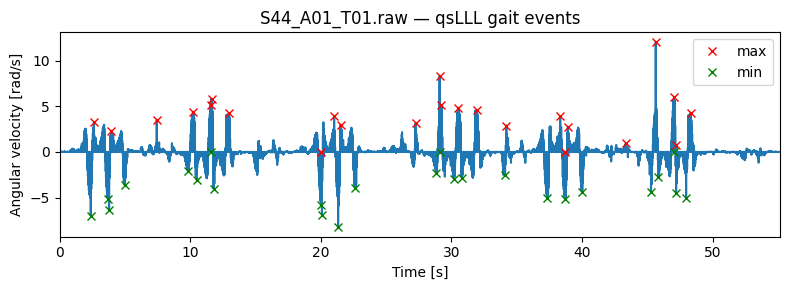

  qsRLL: 110 peaks, 105 troughs


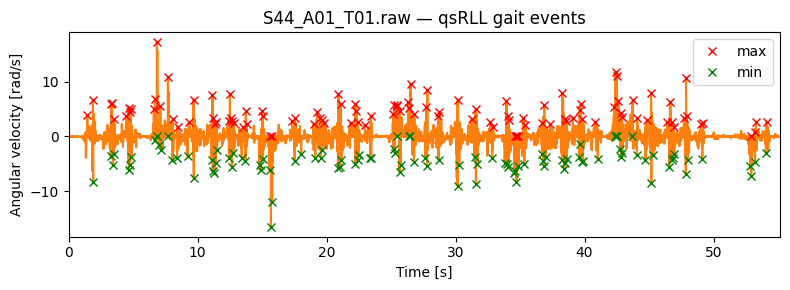


=== Subject S46 ===
Processing S46_A01_T01.raw
  qsLLL: 165 peaks, 162 troughs


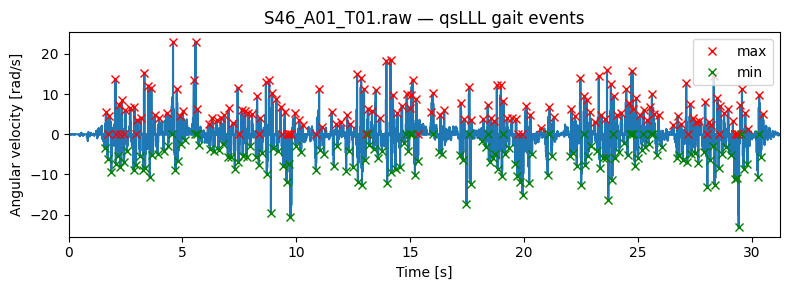

  qsRLL: 28 peaks, 29 troughs


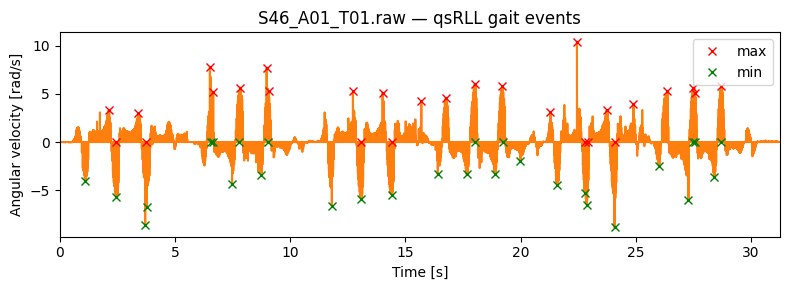


=== Subject S47 ===
Processing S47_A01_T01.raw
  qsLLL: 27 peaks, 30 troughs


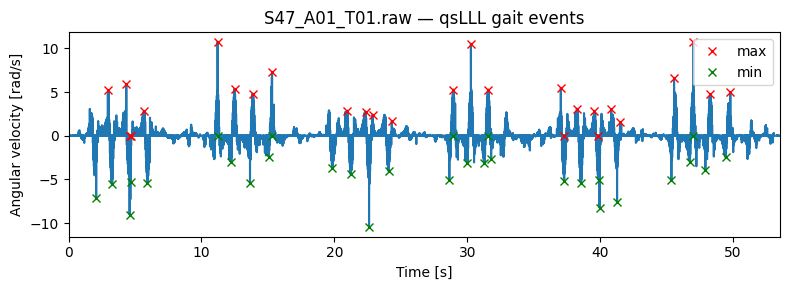

  qsRLL: 31 peaks, 31 troughs


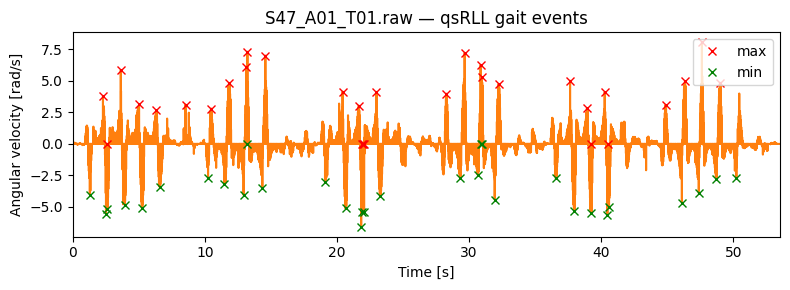


=== Subject S48 ===
Processing S48_A01_T01.raw
  qsLLL: 17 peaks, 17 troughs


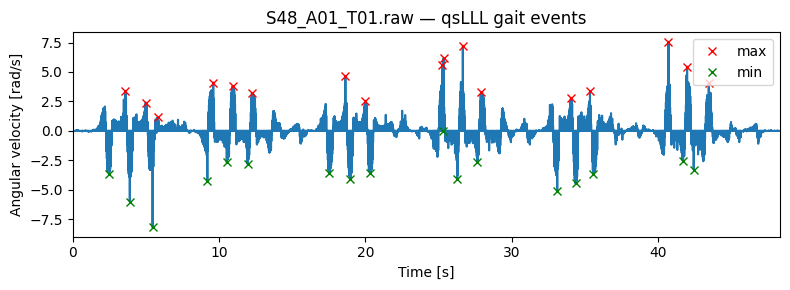

  qsRLL: 20 peaks, 21 troughs


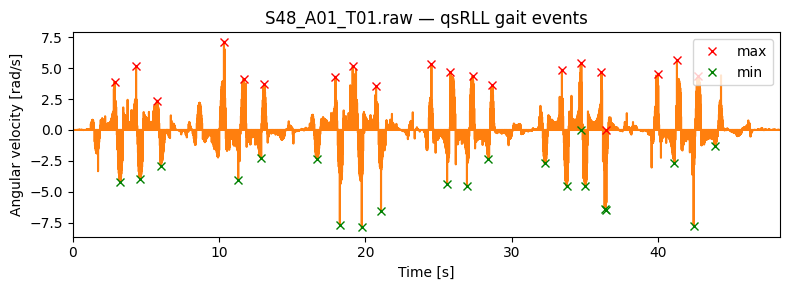


=== Subject S49 ===
Processing S49_A01_T02.raw
  qsLLL: 22 peaks, 19 troughs


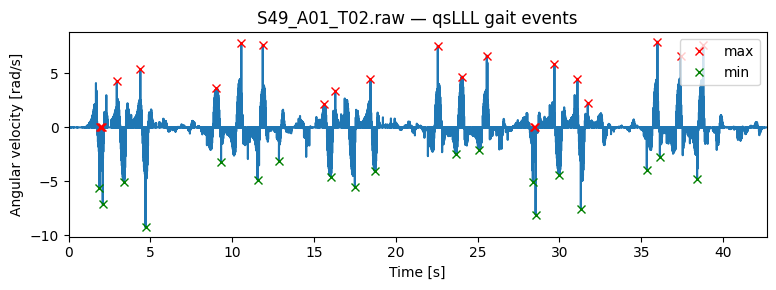

  qsRLL: 19 peaks, 19 troughs


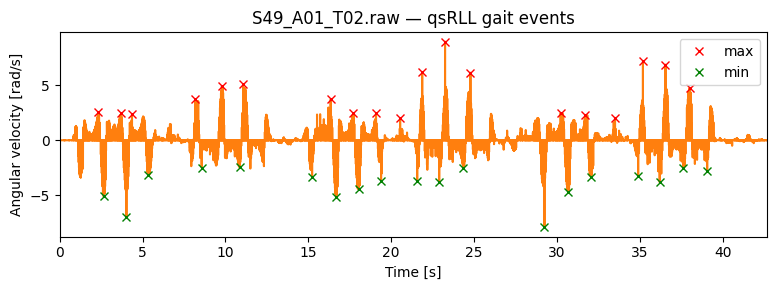


=== Subject S50 ===
Processing S50_A01_T03.raw
  qsLLL: 28 peaks, 24 troughs


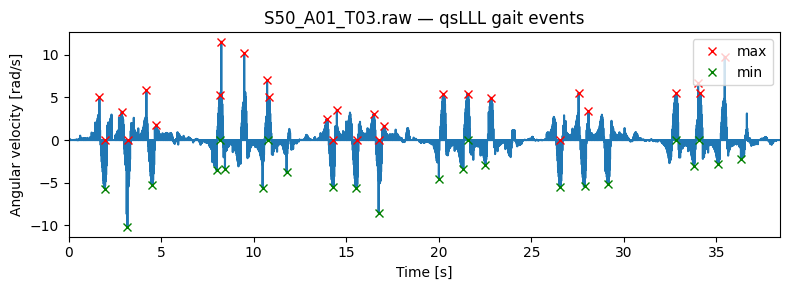

  qsRLL: 55 peaks, 51 troughs


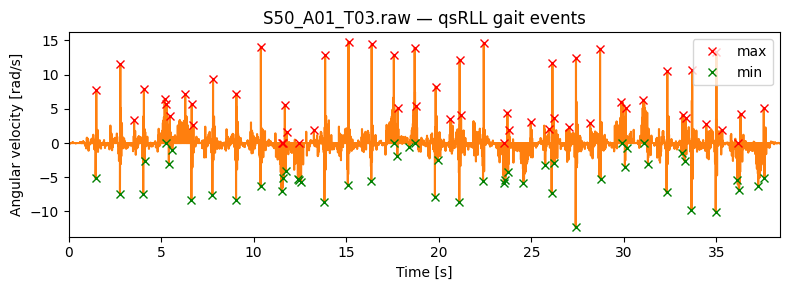


=== Subject S51 ===
Processing S51_A01_T02.raw
  qsLLL: 23 peaks, 23 troughs


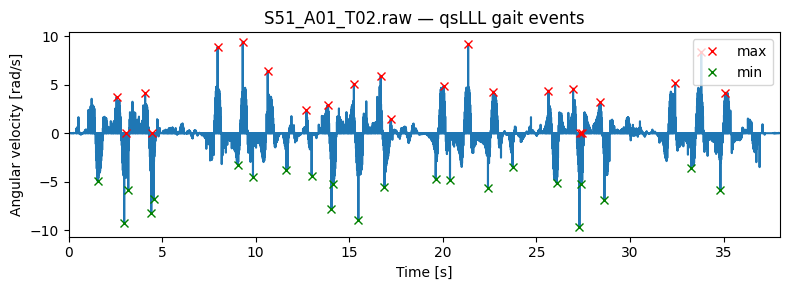

  qsRLL: 27 peaks, 28 troughs


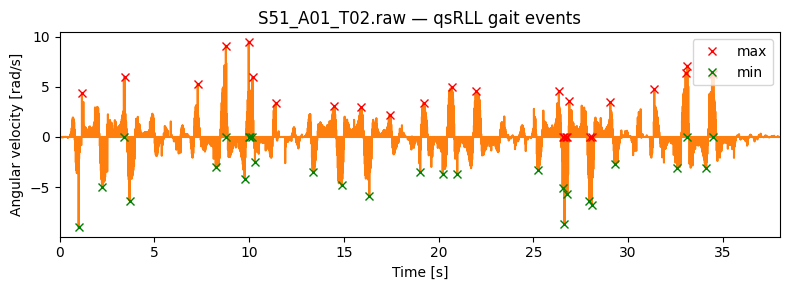


=== Subject S52 ===
Processing S52_A01_T02.raw
  qsLLL: 22 peaks, 23 troughs


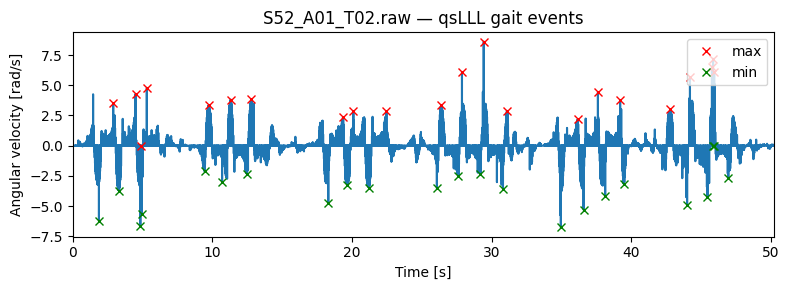

  qsRLL: 19 peaks, 21 troughs


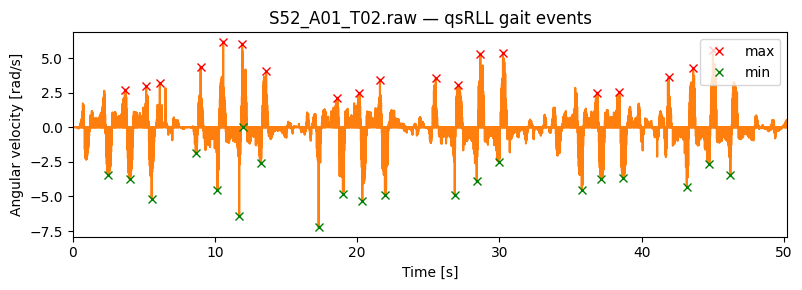


=== Subject S53 ===
Processing S53_A01_T02.raw
  qsLLL: 43 peaks, 40 troughs


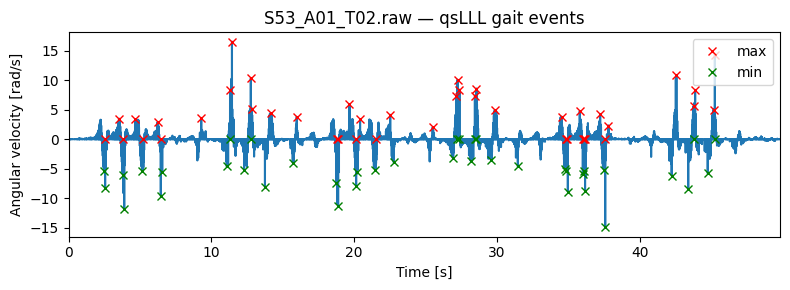

  qsRLL: 42 peaks, 34 troughs


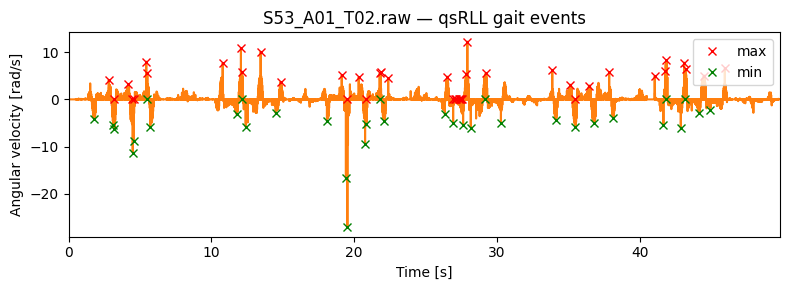


=== Subject S54 ===
Processing S54_A01_T03.raw
  qsLLL: 22 peaks, 22 troughs


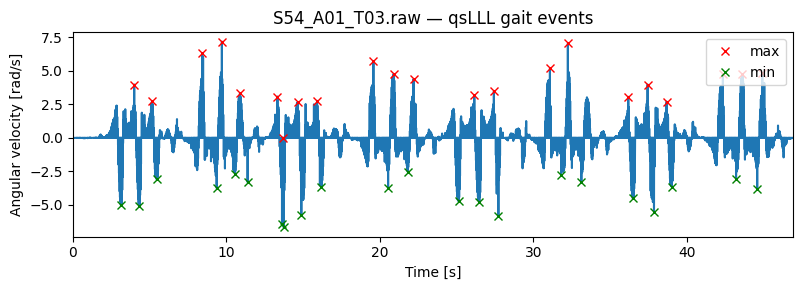

  qsRLL: 27 peaks, 38 troughs


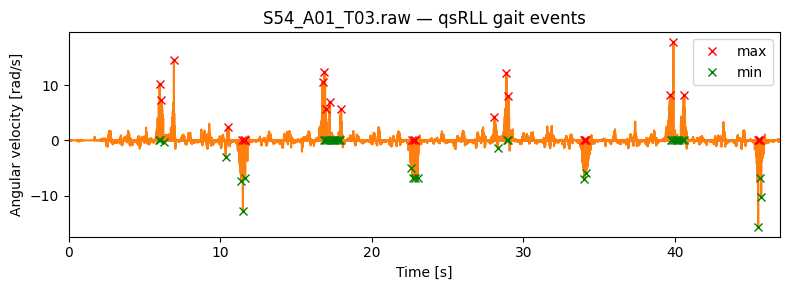


=== Subject S55 ===
Processing S55_A01_T02.raw
  qsLLL: 21 peaks, 24 troughs


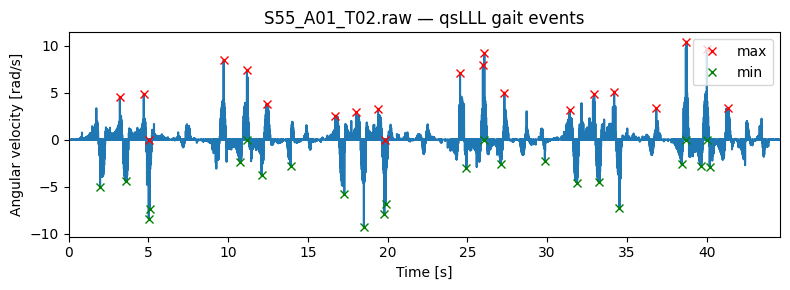

  qsRLL: 24 peaks, 24 troughs


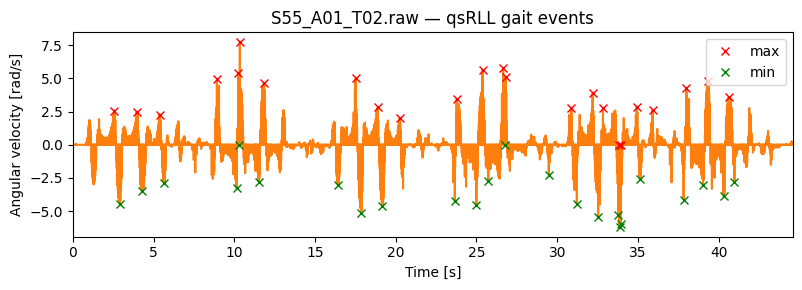


=== Subject S56 ===
Processing S56_A01_T01.raw
  qsLLL: 46 peaks, 42 troughs


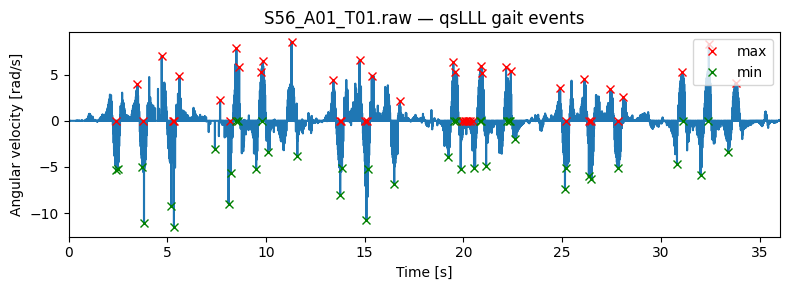

  qsRLL: 40 peaks, 41 troughs


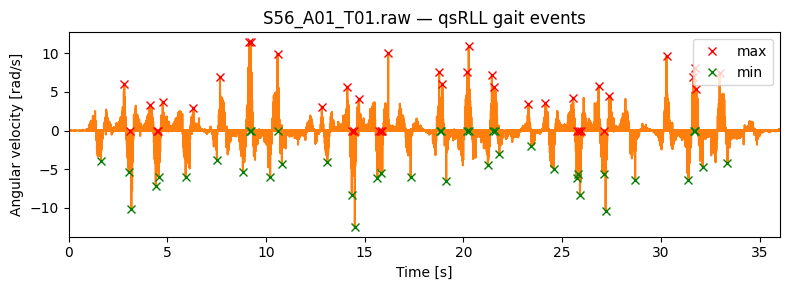


=== Subject S57 ===
Processing S57_A01_T02.raw
  qsLLL: 36 peaks, 39 troughs


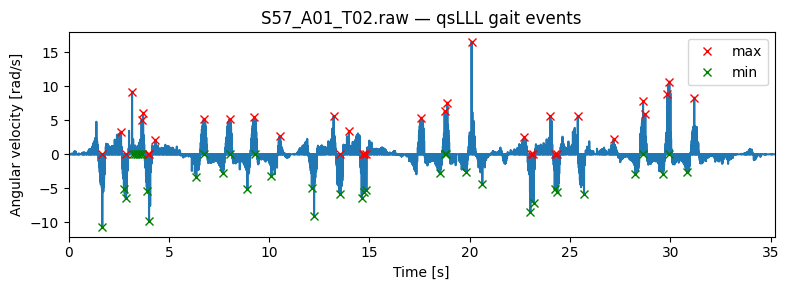

  qsRLL: 39 peaks, 38 troughs


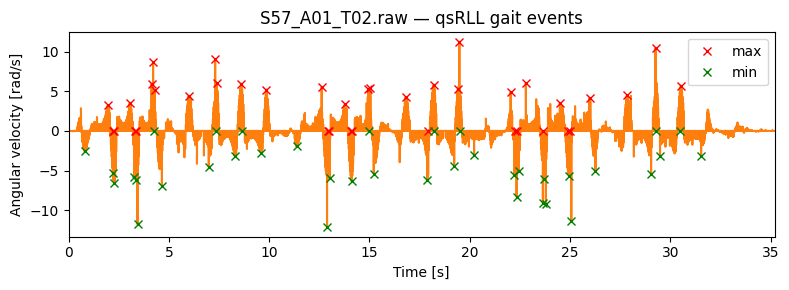

In [85]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# --- Configuration ---
root_dir = '/Users/mario/Documents/TFG_VIDIMU/vidiMU/benchmark/jointangles/jointangles_imus'
sensors  = ['qsLLL', 'qsRLL']
colors   = {'qsLLL': 'tab:blue', 'qsRLL': 'tab:orange'}
fs       = 50                    # IMU sample rate [Hz]
dt       = 1.0 / fs              # constant time step

# --- Quaternion helpers ---
def quat_conjugate(q):
    qc = q.copy()
    qc[...,1:] *= -1
    return qc

def quat_multiply(a, b):
    w1,x1,y1,z1 = a[...,0],a[...,1],a[...,2],a[...,3]
    w2,x2,y2,z2 = b[...,0],b[...,1],b[...,2],b[...,3]
    return np.stack([
        w1*w2 - x1*x2 - y1*y2 - z1*z2,
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2
    ], axis=-1)

def process_file(file_path):
    # Load & clean
    df = pd.read_csv(file_path, header=0)
    df.rename(columns={df.columns[0]:'sensor'}, inplace=True)
    for c in ['w','x','y','z','timestamp']:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df.dropna(subset=['w','x','y','z','timestamp'], inplace=True)
    df = df[df['timestamp'] != 0.0]

    for sensor in sensors:
        grp = df[df['sensor']==sensor] \
                .sort_values('timestamp') \
                .reset_index(drop=True)
        if len(grp) < 2:
            print(f"  {sensor}: not enough data, skipping")
            continue

        # Extract quats & time
        quats      = grp[['w','x','y','z']].values.copy()
        timestamps = grp['timestamp'].values
        t          = (timestamps - timestamps[0])        # seconds

        # Enforce quaternion continuity
        for i in range(1, len(quats)):
            if np.dot(quats[i-1], quats[i]) < 0:
                quats[i] = -quats[i]

        # Compute angular velocity
        q0        = quats[:-1]
        q1        = quats[1:]
        dq        = quat_multiply(q1, quat_conjugate(q0))
        w_clipped = np.clip(dq[:,0], -1.0, 1.0)
        angle     = 2 * np.arccos(w_clipped)
        sin_h     = np.sqrt(1 - w_clipped*w_clipped)
        axis      = np.zeros((len(dq), 3))
        mask      = sin_h > 1e-8
        axis[mask] = dq[mask,1:] / sin_h[mask,None]
        omega3d   = axis * (angle/dt)[:,None]
        t_omega   = t[1:]

        # Select signed component
        axis_idx   = np.argmax(np.std(omega3d, axis=0))
        omega_comp = omega3d[:, axis_idx]

        # --- Plot angular velocity for this sensor ---
        # plt.figure(figsize=(8,3))
        # plt.plot(t_omega, omega_comp,
        #          color=colors[sensor],
        #          label=f'{sensor} ω[{axis_idx}]')
        # plt.xlim(0, t_omega[-1])
        # plt.xlabel('Time [s]')
        # plt.ylabel('Angular velocity [rad/s]')
        # plt.title(f'{os.path.basename(file_path)} — {sensor} ω')
        # plt.legend(loc='upper right')
        # plt.tight_layout()
        # plt.show()

        # Detect gait events
        min_dist   = int(0.5 * fs)
        peaks, _   = find_peaks(   omega_comp, distance=min_dist, prominence=5)
        troughs,_  = find_peaks(- omega_comp, distance=min_dist, prominence=5)
        print(f'  {sensor}: {len(peaks)} peaks, {len(troughs)} troughs')

        # --- Plot gait events for this sensor ---
        plt.figure(figsize=(8,3))
        plt.plot(t_omega, omega_comp, color=colors[sensor])
        plt.plot(t_omega[peaks],   omega_comp[peaks],
                 'xr', label='max')
        plt.plot(t_omega[troughs], omega_comp[troughs],
                 'xg', label='min')
        plt.xlim(0, t_omega[-1])
        plt.xlabel('Time [s]')
        plt.ylabel('Angular velocity [rad/s]')
        plt.title(f'{os.path.basename(file_path)} — {sensor} gait events')
        plt.legend(loc='upper right')
        plt.tight_layout()
        plt.show()

# --- Batch process A01 files ---
for subj in sorted(os.listdir(root_dir)):
    subj_dir = os.path.join(root_dir, subj)
    if not os.path.isdir(subj_dir):
        continue
    print(f"\n=== Subject {subj} ===")
    for fname in sorted(os.listdir(subj_dir)):
        if '_A01_' in fname and fname.endswith('.raw'):
            print(f"Processing {fname}")
            process_file(os.path.join(subj_dir, fname))
